# LangGraph 운동 추천 실습

In [ ]:
!pip install langchain langgraph langchain-community chromadb sqlite-utils

In [2]:
from typing import TypedDict

from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import END, StateGraph


# 1. 상태 정의
class AgentState(TypedDict):
    query: str
    symptoms: str
    exercise_candidates: str
    result: str


# 2. LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")


In [3]:
# 3. 추출에이전트: 사용자의 질문에서 증상 추출
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 건강 상태나 증상에 해당하는 표현만 추출하세요.

출력 형식:
- 증상1
- 증상2
- 증상3

질문: {query}
""")


def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})
    return {**state, "symptoms": symptoms.strip()}


# 4. 후보에이전트: 증상을 해결할 수 있는 운동 리스트 추출
candidate_prompt = PromptTemplate.from_template("""
다음 증상을 개선하는 데 도움이 될 수 있는 운동을 5개 추천하세요.
운동은 초보자가 시작하기 쉬운 순서로 나열하고, 각 운동마다 짧은 이유를 붙이세요.

출력 형식:
- 운동명: 추천 이유

증상:
{symptoms}
""")


def candidate_agent(state: AgentState):
    chain = candidate_prompt | llm
    candidates = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercise_candidates": candidates.strip()}


# 5. 답변생성에이전트: 증상과 운동 리스트를 개조식으로 출력
answer_prompt = PromptTemplate.from_template("""
아래 증상과 운동 후보를 바탕으로 사용자에게 줄 최종 답변을 한국어 개조식으로 작성하세요.

반드시 다음 형식을 지키세요.

## 추출된 증상
- ...

## 추천 운동 리스트
- 운동명: 이유

## 시작 방법
- 첫 주에 실천할 수 있는 간단한 방법 2~3개

주의: 의학적 진단처럼 말하지 말고, 통증이나 어지러움이 있으면 전문가와 상담하라는 문장을 포함하세요.

증상:
{symptoms}

운동 후보:
{exercise_candidates}
""")


def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"],
    })
    return {**state, "result": answer.strip()}


In [4]:
# 6. LangGraph 구성
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("candidate", candidate_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")
graph.add_edge("extractor", "candidate")
graph.add_edge("candidate", "answer")
graph.add_edge("answer", END)

app = graph.compile()

print("============================== LangGraph 구조:")
app.get_graph().print_ascii()


============================== LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| candidate |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [5]:
# 7. 실행 예시
query = "체력이 안좋고 살이 계속 찌는데 어떤 운동을 할까?"
result = app.invoke({"query": query})

print("============================== 사용자 질문:")
print(query)

print("\n============================== 추출된 증상:")
print(result["symptoms"])

print("\n============================== 운동 후보:")
print(result["exercise_candidates"])

print("\n============================== 최종 답변:")
print(result["result"])


============================== 사용자 질문:
체력이 안좋고 살이 계속 찌는데 어떤 운동을 할까?

============================== 추출된 증상:
- 체력 저하
- 체중 증가

============================== 운동 후보:
## 체력 저하 및 체중 증가 개선 운동 추천 (초보자 우선)

**1. 걷기:**

* **추천 이유:** 누구나 쉽게 시작할 수 있으며, 꾸준히 실천하기 용이합니다. 기초 체력 향상과 체지방 감소에 효과적입니다. 거리와 시간을 천천히 늘려나가면 더욱 효과적입니다.

**2. 요가:**

* **추천 이유:** 신체 유연성 향상과 균형 감각 개발에 도움을 줍니다. 근육 이완 효과가 있어 스트레스 완화에도 효과적이며, 체중 증가를 유발하는 불필요한 근육 발달을 방지합니다. 다양한 초보자 요가 프로그램을 활용하면 좋습니다.

**3. 가벼운 저항 운동 (아ーム 컬, 스쿼트 등):**

* **추천 이유:** 근력 강화에 효과적이며, 근육량 증가를 통해 기초대사량을 높여 에너지 소비를 증가시킵니다. 장비 없이도 집에서 간단히 수행 가능하며, 점진적으로 무게를 늘려가는 것이 중요합니다.

**4.   swimming 또는 사이클링 (저강도):**

* **추천 이유:**  심장 건강 증진과 관절 부담을 줄여줍니다. 유산소 운동으로 칼로리 소모가 높아 체중 관리에 도움을 주며, 근력 강화 효과도 기대할 수 있습니다. 부상 위험을 줄이기 위해 점진적으로 강도를 높여나가세요.

**5. 필라테스:**

* **추천 이유:** 코어 근육 강화와 자세 교정에 효과적입니다. 근육 균형을 잡아 체중 분산을 돕고, 부상 예방에도 도움을 줄 수 있습니다. 다양한 기구나 매트만 있으면 집에서도 쉽게 시작 가능합니다.

============================== 최종 답변:
## 추출된 증상
- 체력 저하와 체중 증가가 관찰됨

## 추천 운동 리스트
- **걷기**: 기초 체력 향상과

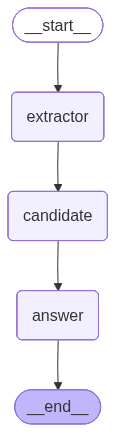

In [6]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))
